# Multi-dataset sentiment EDA

Exploratory comparison of sentiment-related datasets under `data/datasets/`. This notebook is **read-only** for source CSVs: standardized previews are built in memory only.

**Note:** This notebook loads **full** CSVs by default for accurate EDA (may be slow or memory-heavy on large machines).

In [2]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve project root whether the kernel cwd is repo root or notebooks/
_here = Path.cwd().resolve()
if (_here / "data" / "datasets").is_dir():
    PROJECT_ROOT = _here
elif (_here.parent / "data" / "datasets").is_dir():
    PROJECT_ROOT = _here.parent
else:
    raise FileNotFoundError("Run this notebook from the project root or notebooks/ so data/datasets is discoverable.")

DATASETS_ROOT = PROJECT_ROOT / "data" / "datasets"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Optional: set MAX_ROWS = 50_000 to pass into load_by_spec for quick tests only
MAX_ROWS = None

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)

try:
    from IPython.display import display
except ImportError:

    def display(obj: object) -> None:
        print(obj)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MAX_ROWS (None = full load):", MAX_ROWS)

PROJECT_ROOT: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis
MAX_ROWS (None = full load): None


In [4]:
def read_csv_safe(path: Path, **kwargs) -> pd.DataFrame:
    """Load CSV with utf-8 first; fall back to latin-1 for legacy encodings."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    read_kw = {"low_memory": False, **kwargs}
    try:
        return pd.read_csv(path, encoding="utf-8", **read_kw)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1", **read_kw)


URL_RE = re.compile(r"https?://\S+|www\.\S+", re.I)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#\w+")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001F9FF"
    "\u2600-\u26FF\u2700-\u27BF"
    "]+",
    flags=re.UNICODE,
)


def infer_text_column(columns: list[str]) -> str | None:
    priority = [
        "clean_text",
        "text",
        "tweet_text",
        "Tweet",
        "review",
        "Review",
        "comment",
        "body",
        "content",
    ]
    lower_map = {c.lower(): c for c in columns}
    for name in priority:
        if name in columns:
            return name
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    for c in columns:
        if "text" in c.lower():
            return c
    return None


def infer_label_column(columns: list[str], skip: set[str] | None = None) -> str | None:
    skip = skip or set()
    candidates = [
        "label",
        "is_there_an_emotion_directed_at_a_brand_or_product",
        "sentiment",
        "polarity",
        "rating",
        "Rating",
        "target",
        "class",
    ]
    lower_map = {c.lower(): c for c in columns}
    for name in candidates:
        if name in columns and name not in skip:
            return name
        if name.lower() in lower_map and lower_map[name.lower()] not in skip:
            return lower_map[name.lower()]
    return None


def pct(series: pd.Series) -> float:
    return float(100.0 * series.mean()) if len(series) else 0.0


def char_word_lengths(s: pd.Series) -> tuple[pd.Series, pd.Series]:
    s = s.fillna("").astype(str)
    char_len = s.str.len()
    word_len = s.str.split().str.len().clip(lower=0)
    return char_len, word_len


def text_pattern_stats(text_series: pd.Series) -> dict[str, float]:
    s = text_series.fillna("").astype(str)
    nonempty = s.str.len() > 0
    base = nonempty.sum()
    if base == 0:
        return {"url_pct": 0.0, "mention_pct": 0.0, "hashtag_pct": 0.0, "emoji_pct": 0.0}
    sub = s[nonempty]
    return {
        "url_pct": 100.0 * sub.str.contains(URL_RE, regex=True).mean(),
        "mention_pct": 100.0 * sub.str.contains(MENTION_RE, regex=True).mean(),
        "hashtag_pct": 100.0 * sub.str.contains(HASHTAG_RE, regex=True).mean(),
        "emoji_pct": 100.0 * sub.str.contains(EMOJI_RE, regex=True).mean(),
    }


def plot_label_counts(counts: pd.Series, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    counts.sort_index().plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("label")
    ax.set_ylabel("count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_hist_length(lengths: pd.Series, title: str, xlabel: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 4))
    lengths.clip(upper=lengths.quantile(0.99)).hist(bins=40, ax=ax)
    ax.set_title(title + " (clipped at 99th pct for display)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


def interpret_labels(unique_vals) -> str:
    """Short guess for common sentiment encodings."""
    try:
        nums = sorted({float(x) for x in unique_vals if str(x).replace(".", "", 1).isdigit() or (isinstance(x, (int, float)) and not pd.isna(x))})
    except Exception:
        nums = []
    if nums == [0.0, 2.0, 4.0] or set(str(v) for v in unique_vals) >= {"0", "2", "4"}:
        return "Likely Sentiment140-style: 0=neg, 2=neu, 4=pos (check polarity column)."
    if nums == [0.0, 1.0]:
        return "Binary numeric (0/1); map to neg/pos or check docs."
    if all(isinstance(x, str) for x in unique_vals if pd.notna(x)):
        low = {str(x).lower() for x in unique_vals if pd.notna(x)}
        if low <= {"negative", "neutral", "positive"}:
            return "Already lowercase string tri-class; can map to 0/1/2 directly."
        if "negative emotion" in low or "positive emotion" in low:
            return "Brand-emotion strings; needs mapping to 3-class sentiment."
    return "Review label semantics against dataset documentation before mapping to {neg,neu,pos}."


comparison_rows: list[dict] = []

## Dataset definitions

Each entry describes how to load one logical dataset. Twitter **train** has labels; **test** in this folder is text-only (inference set for the brand task).

In [5]:
DATASET_SPECS: list[dict] = [
    {
        "source_dataset": "reddit_ml_ready",
        "path": DATASETS_ROOT / "reddit_comments" / "reddit_comments_ml_ready.csv",
        "loader": "csv",
        "text_col": "clean_text",
        "label_col": "label",
        "notes": "Pre-cleaned text + numeric label.",
    },
    {
        "source_dataset": "sentiment140_train",
        "path": DATASETS_ROOT / "sentiment140" / "training.1600000.processed.noemoticon.csv",
        "loader": "sentiment140",
        "text_col": "text",
        "label_col": "polarity",
        "notes": "Classic Sentiment140: polarity 0/2/4, no header row.",
    },
    {
        "source_dataset": "twitter_brand_train",
        "path": DATASETS_ROOT / "twitter-sentiment" / "Dataset - Train.csv",
        "loader": "csv",
        "text_col": "tweet_text",
        "label_col": "is_there_an_emotion_directed_at_a_brand_or_product",
        "notes": "Brand-directed emotion labels (project train split).",
    },
    {
        "source_dataset": "twitter_brand_test",
        "path": DATASETS_ROOT / "twitter-sentiment" / "Dataset - Test.csv",
        "loader": "csv",
        "text_col": "Tweet",
        "label_col": None,
        "notes": "Test file has Tweet column only (no labels in CSV).",
    },
]

## Per-dataset EDA (A–E)

For each dataset: load, schema, standardized preview, labels, text stats, quality checks.

In [6]:
def load_by_spec(spec: dict) -> pd.DataFrame:
    path = spec["path"]
    loader = spec["loader"]
    if loader == "sentiment140":
        cols = ["polarity", "tweet_id", "date", "query", "user", "text"]
        if MAX_ROWS is not None:
            return read_csv_safe(path, header=None, names=cols, nrows=MAX_ROWS, on_bad_lines="skip")
        return read_csv_safe(path, header=None, names=cols, on_bad_lines="skip")
    if MAX_ROWS is not None:
        return read_csv_safe(path, nrows=MAX_ROWS)
    return read_csv_safe(path)


def section_a_load_inspect(df: pd.DataFrame, spec: dict) -> tuple[str | None, str | None]:
    name = spec["source_dataset"]
    print("\n" + "=" * 80)
    print(f"## A. Load + inspect — {name}")
    print("=" * 80)
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(5))
    nulls = df.isna().sum()
    print("\nnull counts (top non-zero):")
    print(nulls[nulls > 0].sort_values(ascending=False).head(20))
    dup_rows = int(df.duplicated().sum())
    print(f"\nduplicate rows (full-row): {dup_rows}")

    text_col = spec.get("text_col") or infer_text_column(list(df.columns))
    skip = {text_col} if text_col else set()
    label_col = spec.get("label_col")
    if label_col is not None and label_col not in df.columns:
        label_col = infer_label_column(list(df.columns), skip=skip)
    elif label_col is None:
        label_col = infer_label_column(list(df.columns), skip=skip)

    print(f"\nInferred / configured text column: {text_col}")
    print(f"Inferred / configured label column: {label_col}")
    print("\nSchema note:", spec.get("notes", ""))
    if text_col is None:
        print("⚠ No text column available — skip text-length and pattern stats; this table is not a text-sentiment corpus as-is.")
    return text_col, label_col


def section_b_standardize(df: pd.DataFrame, text_col: str | None, label_col: str | None, source: str) -> pd.DataFrame:
    print(f"\n## B. Standardize schema preview — {source}")
    out = pd.DataFrame({
        "text": df[text_col].astype(str) if text_col and text_col in df.columns else pd.Series([""] * len(df)),
        "label": df[label_col] if label_col and label_col in df.columns else pd.NA,
        "source_dataset": source,
    })
    display(out.head(5))
    return out


def section_c_labels(preview: pd.DataFrame, source: str) -> None:
    print(f"\n## C. Label analysis — {source}")
    labels = preview["label"]
    if labels.isna().all():
        print("No labels in standardized preview (e.g. inference-only test set).")
        return
    uniq = labels.dropna().unique()
    print("unique labels (sample):", sorted(uniq, key=lambda x: str(x))[:30], "..." if len(uniq) > 30 else "")
    print("n unique:", len(uniq))
    counts = labels.value_counts(dropna=False)
    print("\nlabel counts:")
    print(counts)
    print("\nInterpretation:", interpret_labels(uniq))
    print(
        "Remap to negative=0, neutral=1, positive=2: depends on encoding above; "
        "Sentiment140 often 0/2/4 → map to 0/1/2; Reddit may be binary 0/4—verify on full data."
    )
    plot_label_counts(counts, f"Class distribution — {source}")


def section_d_text(preview: pd.DataFrame, source: str) -> dict:
    print(f"\n## D. Text analysis — {source}")
    s = preview["text"]
    if s.eq("").all() or (s == "nan").all():
        print("No usable text column — skipping.")
        return {"avg_words": None, "median_words": None}
    char_len, word_len = char_word_lengths(s)
    print("char length — mean:", float(char_len.mean()), "median:", float(char_len.median()))
    print("word length — mean:", float(word_len.mean()), "median:", float(word_len.median()))
    plot_hist_length(char_len, f"Character lengths — {source}", "characters")
    plot_hist_length(word_len, f"Word lengths — {source}", "words")
    # shortest / longest (non-empty)
    nonempty = preview.assign(_w=word_len)[word_len > 0]
    if len(nonempty):
        short_idx = nonempty.nsmallest(3, "_w").index
        long_idx = nonempty.nlargest(3, "_w").index
        print("\nSample shortest (by words):")
        for i in short_idx:
            print(" -", repr(preview.loc[i, "text"][:200]))
        print("\nSample longest (by words):")
        for i in long_idx:
            t = preview.loc[i, "text"]
            print(" -", repr(t[:200] + ("..." if len(t) > 200 else "")))
    empty_pct = 100.0 * (word_len == 0).mean()
    near_empty_pct = 100.0 * (word_len <= 2).mean()
    print(f"\nEmpty (0 words): {empty_pct:.2f}%")
    print(f"Near-empty (≤2 words): {near_empty_pct:.2f}%")
    pat = text_pattern_stats(s)
    print("Pattern rates (% of non-empty rows):", pat)
    return {"avg_words": float(word_len.mean()), "median_words": float(word_len.median())}


def section_e_quality(df: pd.DataFrame, preview: pd.DataFrame, text_col: str | None, label_col: str | None, source: str) -> dict:
    print(f"\n## E. Data quality — {source}")
    recs: list[str] = []
    s = preview["text"]
    char_len, word_len = char_word_lengths(s)
    if text_col and text_col in df.columns:
        raw = df[text_col]
        non_str = (~raw.map(lambda x: isinstance(x, str)) & raw.notna()).sum()
        print(f"Non-string text cells (raw column): {int(non_str)}")
        if non_str:
            recs.append("Coerce text column to string before training.")
    exact_dup_text = int(s.duplicated().sum())
    print(f"Exact duplicate texts (preview): {exact_dup_text}")
    if label_col and label_col in df.columns:
        key = preview[["text", "label"]].astype(str)
        d2 = int(key.duplicated().sum())
        print(f"Duplicate (text, label) pairs: {d2}")
    else:
        d2 = 0
        print("Duplicate (text, label): N/A (no labels)")
    if not preview["label"].isna().all():
        vc = preview["label"].value_counts(normalize=True, dropna=True)
        minority = float(vc.min())
        print("Smallest class share:", round(minority * 100, 2), "%")
        if minority < 0.05:
            recs.append("Severe imbalance — consider class weights or resampling.")
        elif minority < 0.15:
            recs.append("Moderate imbalance — monitor macro-F1.")
    short_pct = 100.0 * (word_len <= 2).mean()
    punct_only = s.str.match(r"^[\s\W\d_]+$", na=False)
    punct_pct = 100.0 * punct_only.mean()
    print(f"Very short (≤2 words): {short_pct:.2f}%")
    print(f"Punctuation/numbers-only-ish rows: {punct_pct:.2f}%")
    if short_pct > 5:
        recs.append("Filter or stratify very short texts.")
    if punct_pct > 1:
        recs.append("Review punctuation-only rows for noise.")
    print("\nRecommendations:")
    for r in recs or ["No major red flags from these heuristics."]:
        print(" -", r)
    null_pct = 100.0 * preview.isna().mean().mean()
    dup_pct = 100.0 * (exact_dup_text / max(len(preview), 1))
    return {"dup_pct": dup_pct, "null_pct": null_pct, "recs": "; ".join(recs)}


## A. Load + inspect — reddit_ml_ready
shape: (1533145, 4)
columns: ['clean_text', 'label', 'word_count', 'avg_word_length']


,clean_text,label,word_count,avg_word_length
0,switchfoot a thats a bummer you shoulda got david carr of third day to do it d,0,17,4.588235
1,is upset that he cant update his facebook by texting it and might cry as a r...,0,21,4.952381
2,kenichan i dived many times for the ball managed to save the rest go out of ...,0,17,4.823529
3,my whole body feels itchy and like its on fire,0,10,4.600000
4,nationwideclass no its not behaving at all im mad why am i here because i ca...,0,21,4.809524



null counts (top non-zero):
Series([], dtype: int64)

duplicate rows (full-row): 0

Inferred / configured text column: clean_text
Inferred / configured label column: label

Schema note: Pre-cleaned text + numeric label.

## B. Standardize schema preview — reddit_ml_ready


,text,label,source_dataset
0,switchfoot a thats a bummer you shoulda got david carr of third day to do it d,0,reddit_ml_ready
1,is upset that he cant update his facebook by texting it and might cry as a r...,0,reddit_ml_ready
2,kenichan i dived many times for the ball managed to save the rest go out of ...,0,reddit_ml_ready
3,my whole body feels itchy and like its on fire,0,reddit_ml_ready
4,nationwideclass no its not behaving at all im mad why am i here because i ca...,0,reddit_ml_ready



## C. Label analysis — reddit_ml_ready
unique labels (sample): [np.int64(0), np.int64(4)] 
n unique: 2

label counts:
label
4    767884
0    765261
Name: count, dtype: int64

Interpretation: Review label semantics against dataset documentation before mapping to {neg,neu,pos}.
Remap to negative=0, neutral=1, positive=2: depends on encoding above; Sentiment140 often 0/2/4 → map to 0/1/2; Reddit may be binary 0/4—verify on full data.


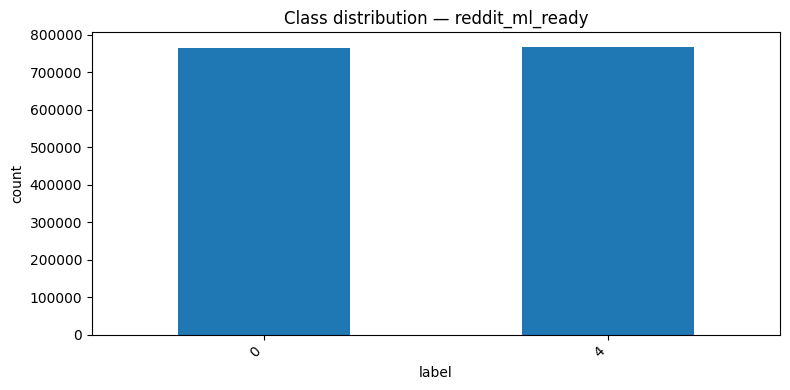


## D. Text analysis — reddit_ml_ready
char length — mean: 69.07470526271162 median: 64.0
word length — mean: 13.231668889765809 median: 12.0


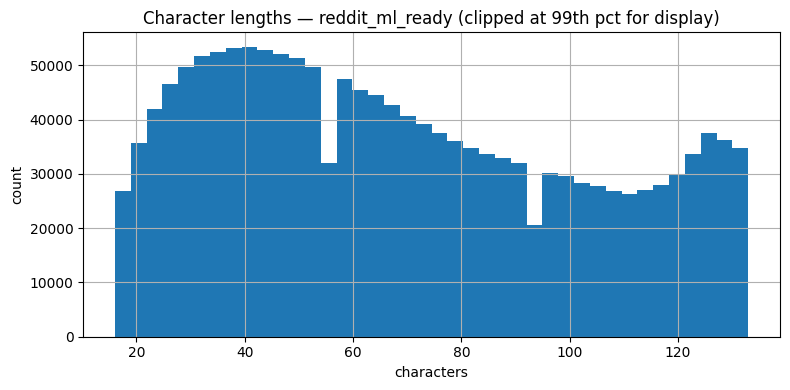

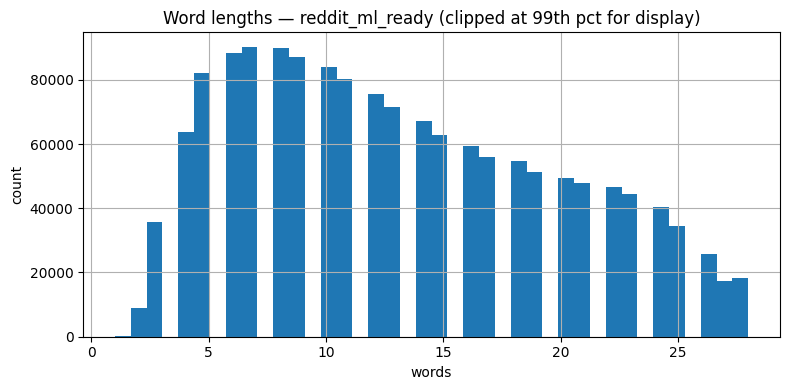


Sample shortest (by words):
 - 'schoolworkouthomehomework'
 - 'fuuuuuuuuuuuuuuuuuuuuuuuuck'
 - 'examsarekillingme'

Sample longest (by words):
 - 'ajayrochester do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it do it'
 - 'im blue da ba dee da ba di da ba dee da ba di da ba dee da ba di da ba dee da ba di da ba dee da ba di the orginal is the only good one'
 - 'ddlovato dont care bout ppl who r saying u r too fat amp then u r too skinny i like u as u r amp u r my role model i love u pls write back'

Empty (0 words): 0.00%
Near-empty (≤2 words): 0.60%
Pattern rates (% of non-empty rows): {'url_pct': np.float64(0.0), 'mention_pct': np.float64(0.0), 'hashtag_pct': np.float64(0.0), 'emoji_pct': np.float64(0.0)}

## E. Data quality — reddit_ml_ready
Non-string text cells (raw column): 0
Exact duplicate texts (preview): 0
Duplicate (text, label) pairs: 0
Smallest class share: 49.91 %
Very short (≤2 words): 0.60%
Punctuation/numb

,polarity,tweet_id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda g..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go ...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? becau..."



null counts (top non-zero):
Series([], dtype: int64)

duplicate rows (full-row): 0

Inferred / configured text column: text
Inferred / configured label column: polarity

Schema note: Classic Sentiment140: polarity 0/2/4, no header row.

## B. Standardize schema preview — sentiment140_train


,text,label,source_dataset
0,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda g...",0,sentiment140_train
1,is upset that he can't update his Facebook by texting it... and might cry as...,0,sentiment140_train
2,@Kenichan I dived many times for the ball. Managed to save 50% The rest go ...,0,sentiment140_train
3,my whole body feels itchy and like its on fire,0,sentiment140_train
4,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? becau...",0,sentiment140_train



## C. Label analysis — sentiment140_train
unique labels (sample): [np.int64(0), np.int64(4)] 
n unique: 2

label counts:
label
0    800000
4    800000
Name: count, dtype: int64

Interpretation: Review label semantics against dataset documentation before mapping to {neg,neu,pos}.
Remap to negative=0, neutral=1, positive=2: depends on encoding above; Sentiment140 often 0/2/4 → map to 0/1/2; Reddit may be binary 0/4—verify on full data.


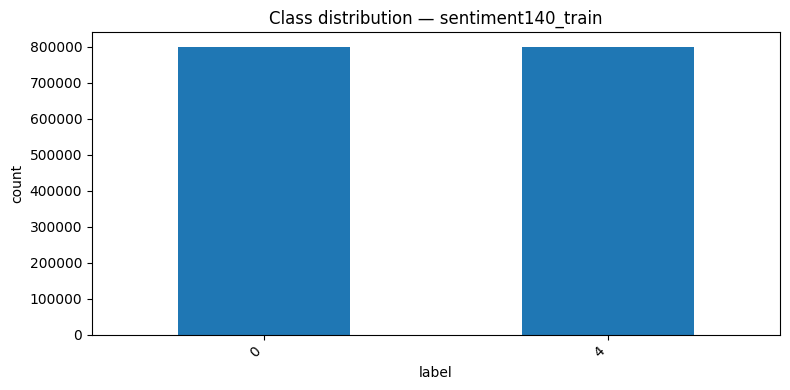


## D. Text analysis — sentiment140_train
char length — mean: 74.09011125 median: 69.0
word length — mean: 13.176150625 median: 12.0


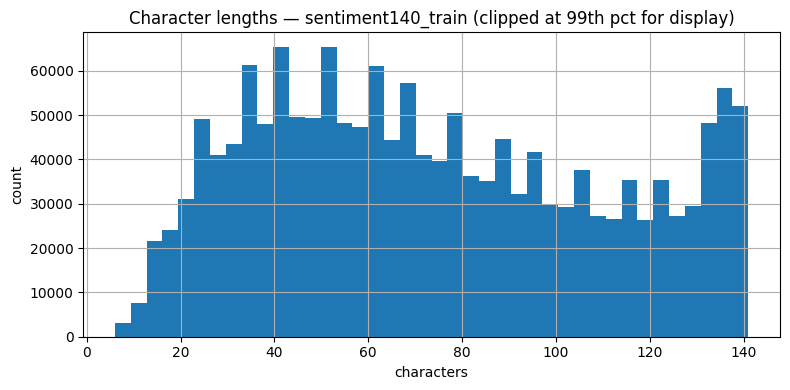

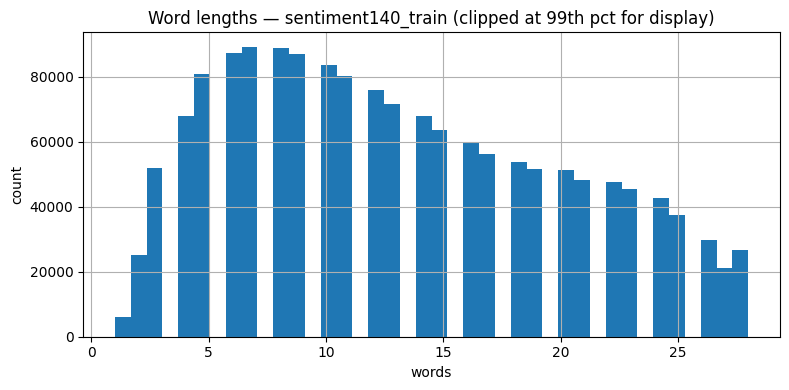


Sample shortest (by words):
 - 'Agh...snow!!! '
 - '@mandayyy '
 - '@mandayyy   '

Sample longest (by words):
 - '? ? ? ? ? ? ? ?? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?Take that '
 - '? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?    ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?     ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?  twitterart '
 - "I'm so boreeeeed. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .I need internet. "

Empty (0 words): 0.00%
Near-empty (≤2 words): 1.94%
Pattern rates (% of non-empty rows): {'url_pct': np.float64(4.7365625), 'mention_pct': np.float64(46.155812499999996), 'hashtag_pct': np.float64(2.2404375), 'emoji_pct': np.float64(0.0)}

## E. Data quality — sentiment140_train
Non-string text cells (raw column): 0
Exact duplicate texts (preview): 18534
Duplicate (text, label) pairs: 16309
Smallest class share: 50.0 %
Very short (≤2 words): 1.94%
Punctuation

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was ...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely a...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app....,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (t...",Google,Positive emotion



null counts (top non-zero):
emotion_in_tweet_is_directed_at    5298
tweet_text                            1
dtype: int64

duplicate rows (full-row): 22

Inferred / configured text column: tweet_text
Inferred / configured label column: is_there_an_emotion_directed_at_a_brand_or_product

Schema note: Brand-directed emotion labels (project train split).

## B. Standardize schema preview — twitter_brand_train


,text,label,source_dataset
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was ...",Negative emotion,twitter_brand_train
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely a...,Positive emotion,twitter_brand_train
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,Positive emotion,twitter_brand_train
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app....,Negative emotion,twitter_brand_train
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (t...",Positive emotion,twitter_brand_train



## C. Label analysis — twitter_brand_train
unique labels (sample): ["I can't tell", 'Negative emotion', 'No emotion toward brand or product', 'Positive emotion'] 
n unique: 4

label counts:
label
No emotion toward brand or product    5389
Positive emotion                      2672
Negative emotion                       519
I can't tell                             9
Name: count, dtype: int64

Interpretation: Brand-emotion strings; needs mapping to 3-class sentiment.
Remap to negative=0, neutral=1, positive=2: depends on encoding above; Sentiment140 often 0/2/4 → map to 0/1/2; Reddit may be binary 0/4—verify on full data.


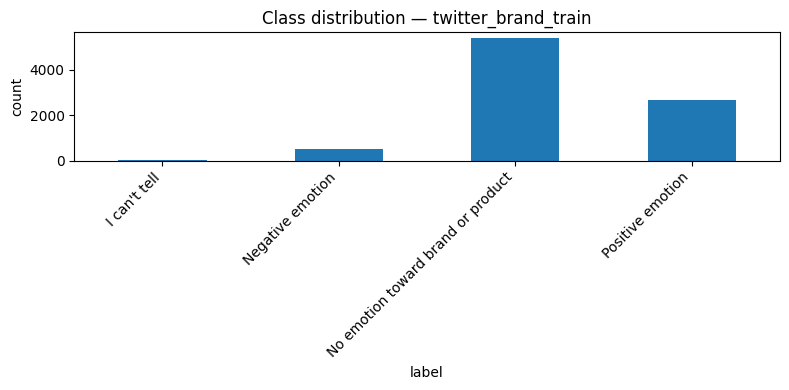


## D. Text analysis — twitter_brand_train
char length — mean: 104.84258935848177 median: 109.0
word length — mean: 17.750844102922343 median: 18.0


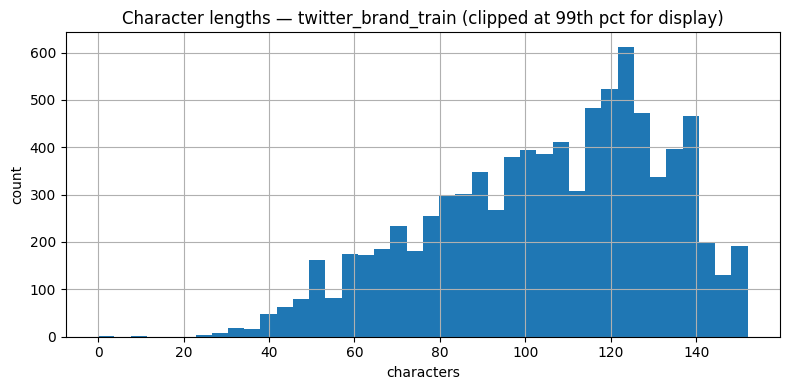

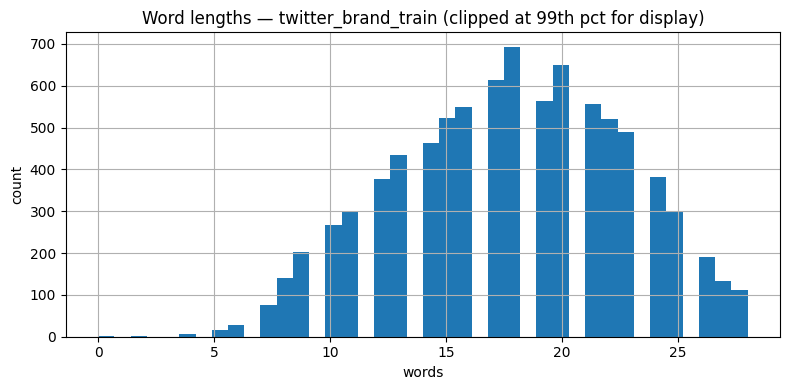


Sample shortest (by words):
 - 'RT @mention'
 - 'Essential #sxsw tools: {link}'
 - '@mention #SXSW iPad rocks'

Sample longest (by words):
 - 'RT @mention Apple fans. It looks like there will be a 3rd Apple store opening up in Austin for #SxSW if those are full, u can go2 1 of 4 in San Antonio.'
 - 'RT @mention every time u hold yur ipad 2 up in the air to snap a pic it reminds me of a priest holding up a bible. except designed in california. #sxsw'
 - 'RT @mention Very happy that Discovr has been named as one of the top ten must-have apps for iPad 2 :) I just have to fight my way thru the queue! #sxsw'

Empty (0 words): 0.01%
Near-empty (≤2 words): 0.02%
Pattern rates (% of non-empty rows): {'url_pct': np.float64(0.4890544946436889), 'mention_pct': np.float64(54.21518397764322), 'hashtag_pct': np.float64(99.93013507219376), 'emoji_pct': np.float64(0.0)}

## E. Data quality — twitter_brand_train
Non-string text cells (raw column): 0
Exact duplicate texts (preview): 27
Duplicate (text,

,Tweet
0,Hand-Held ���Hobo�۪: Drafthouse launches ���Hobo With a Shotgun�۪ iPhone app...
1,Again? RT @mention Line at the Apple store is insane.. #sxsw
2,"Boooo! RT @mention Flipboard is developing an iPhone version, not Android, s..."
3,Thanks to @mention for publishing the news of @mention new medical Apps at t...
4,���@mention &quot;Apple has opened a pop-up store in Austin so the nerds in ...



null counts (top non-zero):
Series([], dtype: int64)

duplicate rows (full-row): 0

Inferred / configured text column: Tweet
Inferred / configured label column: None

Schema note: Test file has Tweet column only (no labels in CSV).

## B. Standardize schema preview — twitter_brand_test


,text,label,source_dataset
0,Hand-Held ���Hobo�۪: Drafthouse launches ���Hobo With a Shotgun�۪ iPhone app...,<NA>,twitter_brand_test
1,Again? RT @mention Line at the Apple store is insane.. #sxsw,<NA>,twitter_brand_test
2,"Boooo! RT @mention Flipboard is developing an iPhone version, not Android, s...",<NA>,twitter_brand_test
3,Thanks to @mention for publishing the news of @mention new medical Apps at t...,<NA>,twitter_brand_test
4,���@mention &quot;Apple has opened a pop-up store in Austin so the nerds in ...,<NA>,twitter_brand_test



## C. Label analysis — twitter_brand_test
No labels in standardized preview (e.g. inference-only test set).

## D. Text analysis — twitter_brand_test
char length — mean: 106.19642857142857 median: 111.0
word length — mean: 17.974206349206348 median: 18.0


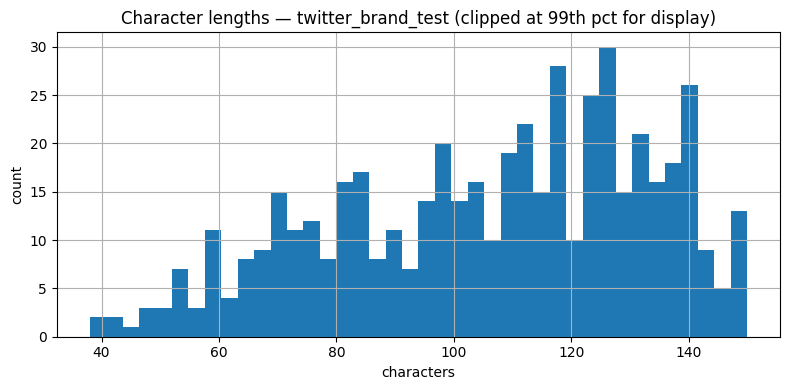

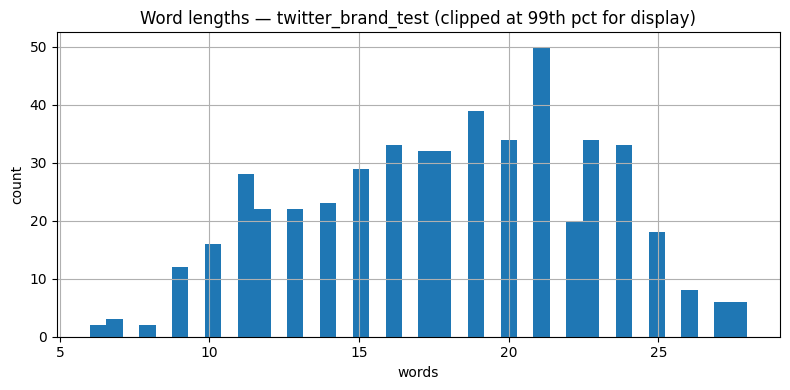


Sample shortest (by words):
 - "The world's largest iPad. #sxsw {link}"
 - 'iphone, ipad, mac Oh my! #agchat,#sxsw'
 - 'Free for #SXSW: fluffertraX Radio #iPhone app--{link}'

Sample longest (by words):
 - 'Line a mile long outside. Lucky to get in just to sit on the floor -Your Mom Has An iPad. I miss the old days at #sxsw before 40% + growth!'
 - "I may not have invites to all the &quot;cool&quot; #sxsw #sxswi parties, but I do have two iPhone chargers in my pocket, so you'll be happy to see me!"
 - '#SXSW attendees - need one of the best QR scanner/creators on your iPhone? Send us a pic of a QR code you found for a free copy of Optiscan'

Empty (0 words): 0.00%
Near-empty (≤2 words): 0.00%
Pattern rates (% of non-empty rows): {'url_pct': np.float64(0.1984126984126984), 'mention_pct': np.float64(52.182539682539684), 'hashtag_pct': np.float64(100.0), 'emoji_pct': np.float64(0.0)}

## E. Data quality — twitter_brand_test
Non-string text cells (raw column): 0
Exact duplicate texts (pre

In [7]:
for spec in DATASET_SPECS:
    df = load_by_spec(spec)
    text_col, label_col = section_a_load_inspect(df, spec)
    preview = section_b_standardize(df, text_col, label_col, spec["source_dataset"])
    section_c_labels(preview, spec["source_dataset"])
    text_stats = section_d_text(preview, spec["source_dataset"])
    q = section_e_quality(df, preview, text_col, label_col, spec["source_dataset"])

    lab_space = "none"
    if label_col and label_col in df.columns:
        lab_space = str(sorted(df[label_col].dropna().unique()[:15])) + ("..." if df[label_col].nunique() > 15 else "")

    comparison_rows.append({
        "dataset": spec["source_dataset"],
        "row_count": len(df),
        "text_column": text_col,
        "label_column": label_col,
        "label_space": lab_space,
        "avg_word_count": text_stats.get("avg_words"),
        "median_word_count": text_stats.get("median_words"),
        "dup_text_pct": round(q["dup_pct"], 3),
        "null_pct_mean_cols": round(q["null_pct"], 3),
        "preprocessing_notes": spec.get("notes", "") + " | " + q["recs"],
    })

print("\nPer-dataset loop complete.")

## F. Cross-dataset comparison

Single table summarizing scale, columns, label space, and rough text stats (on loaded sample).

In [ ]:
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

summary_path = PROCESSED_DIR / "multi_dataset_eda_summary.csv"
comparison_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)

## G. Recommendations & action plan

Heuristic guidance for a **unified** 3-class sentiment dataset (`negative=0`, `neutral=1`, `positive=2`).

In [ ]:
def print_recommendations() -> None:
    print("\n### Ready-ish vs needs work\n")
    print(
        "- **Reddit (`reddit_ml_ready`)**: Text + numeric labels already aligned; confirm label semantics (0/1 binary vs something else) then map to 3-class or keep binary.\n"
        "- **Sentiment140**: Classic 0/2/4 polarity → map to 0/1/2; large scale; sample or stream for training.\n"
        "- **Twitter brand train**: String emotion labels → explicit remap to {negative, neutral, positive} codes.\n"
        "- **Twitter brand test**: No labels — use only for inference / pseudo-labeling, not supervised training loss.\n"
    )
    print("### Label remapping\n")
    print(
        "- Sentiment140: polarity 0→0, 2→1, 4→2.\n"
        "- Twitter train: map emotion strings to 0/1/2 (handle 'No emotion...' as neutral).\n"
        "- Reddit: verify label meaning; if binary, decide neg/pos only or add neutral from another source.\n"
    )
    print("### Column / cleaning\n")
    print(
        "- Standardize to columns `text`, `label_int`, `source_dataset`.\n"
        "- Deduplicate by text (and optionally by text+label).\n"
        "- Drop or flag empty / near-empty texts; normalize URLs and mentions if desired.\n"
        "- Watch encoding (latin-1 vs utf-8) on Sentiment140 / older CSVs.\n"
    )
    print("### Suggested next steps (unified training)\n")
    print(
        "1. Build a preprocessing script that loads each source, applies the remaps above, and outputs `data/processed/unified_sentiment_train.csv`.\n"
        "2. Hold out validation per source or mixed stratified split to detect domain shift.\n"
        "3. Start with a subset (e.g. 50k–200k rows per source) to prototype; then scale.\n"
        "4. Keep Twitter test as a separate inference benchmark; do not merge as training labels.\n"
    )


print_recommendations()
print("\n--- ACTION PLAN (concise) ---")
print(
    "Define label maps → normalize schema → filter bad rows → concat with source tags → "
    "stratified train/val/test → train multi-source model with optional domain features or adversarial training if shift is large."
)